# Enigma da Esfinge: Validação cruzada aninhada

## Introdução

Este notebook refere-se à primeira das duas entregas da disciplina de Aprendizado de máquina, ministrada pelo prof. dr. Daniel R. Cassar na Ilum escola de ciência. De caráter introdutório, o objetivo é apresentar o método de validação cruzada aninhada para modelos de aprendizado de máquina. Ele está dividido em duas partes, a primeira constrói uma linha de raciocínio que irá gradualmente construindo a fundação para entender o método. Enquanto a útima serve não só para construir o método, mas também como um código autocontido para consulta rápida, destinada a alguém que já tenha a base e queira ir direto aos detalhes de implementação.

### Conhecendo nossos dados

Para este caderno, usaremos o DataSet "Water potability" disponibilizado no Kaggle [2]. Segue a lista das colunas com uma breve descrição:

* **Ph**: Avalia o equilíbrio ácido-base da água, indicando condições de acidez e alcalinidade na mesma. A organização mundial da saúde definiu que o intervalo máximo permitido para o Ph é de 6.5 a 8.5;

* **Dureza (hardness)**: Concentração de sais de cálcio e magnésio. No Brasil, a Portaria GM/MS nº 888/2021 define o valor máximo permitido de 300mg/L [3];

* **Sólidos dissolvidos totais (Solids ou TDS)**: Presença de sólidos que alteram a cor e o gosto da água. Alto TDS, indica que está altamente mineralizada. O valor recomendado é de 500mg/L e o máximo é de 1000mg/L;

* **Cloraminas (chloramines)**: Os principais desinfetantes usados em tratamento de água. A presença de cloro na água até 4mg/L ou 4ppm (partes por milhão) é considerada segura;

* **Sulfato (sulfate)**: Substâncias presentes em minerais, solo e pedras. A quantidade presente em água doce fica entre 3 e 30mg/L, com alguns locais podendo chegar em 1000mg/L;

* **Condutividade**: Presença de íons dissolvidos na água aumentam sua condutividade. Portanto, a condutividade elétrica (EC) é uma forma de medir indiretamente a quantidade de íons presentes, não podendo exceder 400$\micro$S/cm.

* **Carbono orgânico (Organic_carbon)**: Mede a quantidade total de carbono orgânico dissolvido na água. Segundo a ANVISA, não pode exceder 5mg/L.

* **Trialometanos (Trihalomethanes)**: Podem ser encontrados em água tratada com cloro. Quantidades até 80 ppm são consideradas seguras para consumo.

* **Turbidez (Turbidity)**: Mede a matéria coloidal dispersa na água através das suas propriedades óticas. O valor recomendado pela OMS é de 5.00 NTU.

* **Potabilidade (Potability)**: Este é o target, ela pode ter os valores 0 ou 1 para não potável ou potável, respectivamente. Mede se a água é própria, ou não, para consumo.


**Quais informações são relevantes?**

Como queremos avaliar a potabilidade da água, não removeremos nenhum destes atributos. Afinal, não seria muito seguro se nosso modelo avaliasse como potável uma água de pH 2.0 porque retiramos este dado, né?

### Sobre os modelos

Conhecendo os dados, agora podemos escolher um modelo. Como o target é uma classe, ou seja, uma categoria, usaremos um modelo de classificação. Mas qual escolher? Para este início, usaremos a Árvore de Decisão e o K Vizinhos mais Próximos (KNN), por serem mais simples de entender. Vamos conhecê-los?

O modelo de Árvore de Decisão tem a forma de um grafo direcional com três tipos vértices/nós (ou nodes, em inglês) [1]:

* Nó raíz: é o início da árvore, por padrão, sairão dele dois nós-filho com base no valor de uma condicional, o chamado _split_. Ex: "Se o número for maior que 10, vá para o nó à esquerda. Se não, vá para direita".
* Nós de decisão: seriam os "galhos" da árvore, partem de um nó-pai que pode ser o raiz ou outro de decisão e dão origem a dois nós-filhos com base em uma condicional.
* Nó folha: surgem quando os dados foram divididos o suficiente e não há necessidade de mais _splits_, são filhos de um único nó-pai e não possuem filhos, sendo o final da árvore. Os nós folha possuem as respostas para as condicionais, anteriores.

O modelo de K Vizinhos mais Próximos vai pegar o dado a ser previsto e colocá-lo num "espaço" onde outros dados obtidos durante a fase de treinamento estão dispersos com base em seus atributos. Ele então irá medir a distância entre o ponto a ser analisado e os K vizinhos mais próximos neste "espaço" [1].

Também usaremos um terceiro modelo, o BaseLine ou Dummy (que significa "bobo" em inglês). Para um problema de classificação, ele sempre irá prever a classe mais recorrente nos dados [4]. Ele servirá como base de comparação para os modelos anteriores, uma vez que é o modelo mais simples possível, espera-se que os demais se saiam consideravelmente melhor que este. Isto é bom para medirmos a viabilidade ao usar um modelo específico, pois, ele esteja muito próximo ou tenha métricas piores que o BaseLine, melhor nem utilizá-lo!

Enfim, para controlar o comportamento destes modelos, como eles aprendem e quais critérios usam, nós usamos hiperparâmetros!

 **Hiper... o quê?**

Os hiperparâmetros são variáveis que escolhemos ao criar o modelo, definindo como ele irá se comportar. Ao contrário de parâmetros do modelo que são aprendidos e ajustados durante o treinamento, os hiperparâmetros são escolhidos antes do treinamento e não podem mais ser mudados. Por isso, é necessário conhecer a melhor combinação possível para poder treinar o modelo da melhor forma [5].

Há uma configuração que fazemos antes de criar nossos modelos que não é um hiperparâmetro:

* ``random_state``: Controla a geração de valores pseudoaletarórios e garante reprodutibilidade. Por não afetar o comportamento e o desempenho do modelo, não é um hiperparâmetro.

Bom, com os conhecimentos básicos cobertos, vamos ao código!

### Embasamento

Para fins didáticos, adotarei uma abordagem gradual para entendermos como é construído um algoritmo de validação cruzada aninhada e o porquê de utilizá-lo. Caso queira pular a explicação e ir para a Validação Cruzada Aninhada propriamente dita, basta ocultar esta célula! Caso queria aprender o embasamento por trás do método, recomendo seguir o fio.

**Mãos na massa!**

Vamos preparar nossos dados. Para isto, usaremos a biblioteca ``pandas`` para organizar e tratar os dados em um DataFrame:

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("water_potability.csv") # Importando os dados
df = df.dropna() # Retirando linhas com dados faltantes
df = df.reset_index(drop=True) # Resetando os índices

In [3]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000
mean,7.085990,195.968072,21917.441374,7.134338,333.224672,426.526409,14.357709,66.400859,3.969729,0.403282
std,1.573337,32.635085,8642.239815,1.584820,41.205172,80.712572,3.324959,16.077109,0.780346,0.490678
min,0.227499,73.492234,320.942611,1.390871,129.000000,201.619737,2.200000,8.577013,1.450000,0.000000
25%,6.089723,176.744938,15615.665390,6.138895,307.632511,366.680307,12.124105,55.952664,3.442915,0.000000
50%,7.027297,197.191839,20933.512750,7.143907,332.232177,423.455906,14.322019,66.542198,3.968177,0.000000
75%,8.052969,216.441070,27182.587067,8.109726,359.330555,482.373169,16.683049,77.291925,4.514175,1.000000
max,14.000000,317.338124,56488.672413,13.127000,481.030642,753.342620,27.006707,124.000000,6.494749,1.000000


Aqui temos uma descrição dos dados presentes, parece razoável.

#### Treinando e testando os modelos usando divisão de treino e teste

Tendo nossos dados, uma estratégia _razoável_ é dividir uma fração destes dados para treinar nossos modelos e outra para testá-los de modo a garantir que eles não simplesmente memorizem as respostas, ao invés de aprender. O que poderia dar errado, não é mesmo? Vamos implementá-los!

In [4]:
# Modelos que serão testados
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

# Métrica de desempenho
from sklearn.metrics import accuracy_score

# Para plotar as métricas de desempenho
import seaborn as sns

# Divisão de treino e teste
from sklearn.model_selection import train_test_split

Vamos definir umas constantes importantes:

In [5]:
SEMENTE = 12151822 # Garante reprodutibilidade de resultados

# Dados a serem analisados
ATRIBUTOS = ['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity']

# Dados a serem previstos
TARGET = ["Potability"]

# Quantos % dos dados reservaremos para teste
FRACAO_TESTE = 0.2

Separando dados de treino e teste pelos índices. X refere-se aos atributos que serão analisados, y refere-se ao valor a ser previsto, nosso target.

In [6]:
indices = df.index

indices_treino, indices_teste = train_test_split(
    indices, test_size=FRACAO_TESTE, random_state=SEMENTE
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

X = df.reindex(ATRIBUTOS, axis=1).values
y = df.reindex(TARGET, axis=1).values.ravel()

Vamos agora usar estes dados para treinar e testar nossos modelos!

In [7]:
modelo_AD = DecisionTreeClassifier(random_state=SEMENTE)
modelo_KNN = KNeighborsClassifier()
modelo_BL = DummyClassifier(random_state=SEMENTE)

modelos = {"Árvore de decisão": modelo_AD, "KNN": modelo_KNN, "BaseLine": modelo_BL}

y_real = y_teste

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    y_previsto = modelo.predict(X_teste)
    
    # Avaliando a acurácia de cada modelo. Ela será explicada mais tarde!
    acuracia = accuracy_score(y_real, y_previsto)
    print(f"A acurácia do modelo {nome} foi {acuracia:.2f}.")
    print("==="*30)

A acurácia do modelo Árvore de decisão foi 0.58.
A acurácia do modelo KNN foi 0.57.
A acurácia do modelo BaseLine foi 0.58.


Fora o fato que todos os modelos estão em pé de igualdade na acurácia, parece estar tudo normal, mas há um problema: na divisão de treino e teste, os modelos estão bastante sujeitos ao acaso, ou seja, o conjunto de dados escolhido para treino e teste pode acabar favorecendo ou prejudicando nossos modelos [1]. Farei uma demonstração:

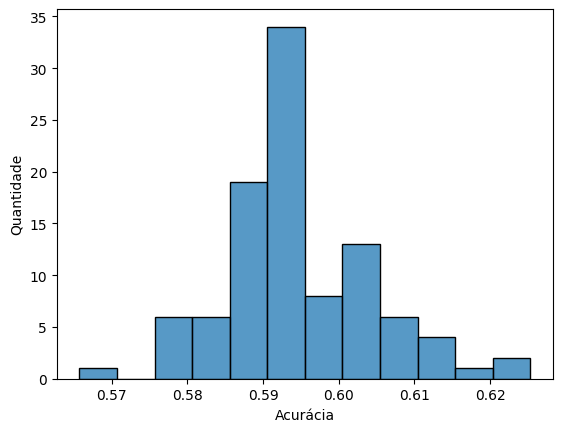

In [8]:
resultado = []

y_real = y_teste

for semente in range(0,100):
    modelo_AD = DecisionTreeClassifier(random_state=semente)
    modelo_AD.fit(X_treino, y_treino)

    y_previsto = modelo_AD.predict(X_teste)

    acuracia = accuracy_score(y_real, y_previsto)

    resultado.append(acuracia)

figura = sns.histplot(resultado)
figura.set(xlabel="Acurácia", ylabel="Quantidade");

Aqui fica bastante claro, variações na semente acabam afetando a acurácia do modelo. Como podemos contornar este problema?

#### Validação cruzada k-fold

Existem vários tipos de validação cruzada na literatura, mas as mais relevantes para este caderno seão a K-Fold e a K-Fold estratificada. A primeira é o método em que os dados de treino são divididos em k partes (os folds), diferentes instâncias dos modelos escolhidos são treinados em k-1 folds, deixando o último como um conjunto de validação para avaliar o desempenho dos modelos [6]. Segue um diagrama que exemplifica seu funcionamento [6]:

![img](https://media.datacamp.com/legacy/v1718738336/image_0bb32b40f1.jpg)

A estratificada, por sua vez, busca manter a representatividade das classes em cada um dos folds. Ou seja, se temos 70% da classe positiva e 30% da classe negativa no DataSet, o K-Fold estratificado irá buscar manter esta proporção em cada um de seus folds.

In [9]:
from sklearn.model_selection import KFold, cross_val_score

Aqui eu resolvi pôr algumas redundâncias para não precisar ficar voltando na sessão anterior.

In [10]:
# Criando instâncias dos modelos
modelo_AD = DecisionTreeClassifier(random_state=SEMENTE)
modelo_KNN = KNeighborsClassifier()
modelo_BL = DummyClassifier(random_state=SEMENTE)

modelos = {"Árvore de decisão": modelo_AD, "KNN": modelo_KNN, "BaseLine": modelo_BL}

k_fold = KFold(n_splits=5, random_state=SEMENTE, shuffle=True)

X = df.reindex(ATRIBUTOS, axis=1).values
y = df.reindex(TARGET, axis=1).values.ravel()

for nome, modelo in modelos.items():
    # Esta função avalia o desempenho do modelo
    scores = cross_val_score(modelo, X, y, cv = k_fold)
    print(f"Os scores do modelo {nome} foram {scores}.")
    print(f"A média dos {len(scores)} scores foi de {scores.mean():.2f}.")
    print("==="*40)

Os scores do modelo Árvore de decisão foram [0.58064516 0.56716418 0.59950249 0.58457711 0.5920398 ].
A média dos 5 scores foi de 0.58.
Os scores do modelo KNN foram [0.56823821 0.50995025 0.56965174 0.59950249 0.58457711].
A média dos 5 scores foi de 0.57.
Os scores do modelo BaseLine foram [0.57816377 0.56467662 0.60945274 0.6318408  0.59950249].
A média dos 5 scores foi de 0.60.


Podemos ver que nenhum modelo teve melhora além do BaseLine que estamos usando como comparação. Isto é perfeitamente esperado, afinal, não estamos escolhendo hiperparâmetros para nossos modelos. Vamos agora discutir um pouco sobre uns aspectos importantes para enfim começarmos a mexer nos hiperparâmetros!

#### Otimização de hiperparâmetros

Como havia dito no início, os hiperparâmetros são variáveis que escolhemos antes de treinar o modelo para mudar seu comportamento [5]. Mas como podemos saber qual combinação será melhor? Vamos antes falar sobre viés e variância: um bom modelo é aquele que equilibra bem estes dois aspectos[7]. Mas o que eles são?

**O equilíbrio viés-variância**

O viés (bias) é a diferença entre as previsões do modelo e a realidade. Modelos com alto viés são subajustados (underfit, no inglês), não conseguindo identificar correlações entre os dados, ou seja, não aprendeu o padrão [7].

Já a variância (variance), é a sensibilidade do modelo a novos dados, modelos com alta variância são muito adaptados aos dados de treinamento (overfit), tendo dificuldades de prever novos dados, pois decoraram os dados e aprenderam até o ruído. O diagrama abaixo mostra o comportamento de um modelo com alto viés, bem equilibrado e com alta variância, respectivamente [7]:

![img](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*0ezlGge0OqGhzMo6HDEA8A.png)

Os modelos com baixo viés são mais precisos, enquanto os com baixa variância são consistentes. Portanto, uma boa otimização de hiperparâmetros busca equilibrar ambos para assim maximizar o desempenho do modelo. O diagrama abaixo mostra o equilíbrio entre viés e variância, o erro total do modelo é a soma entre estas duas grandezas [7]:

![img](https://miro.medium.com/v2/resize:fit:750/format:webp/0*UDp6phojWvlixHO9)

**Como podemos encontrar os melhores hiperparâmetros para nosso modelo?**

Dificilmente acharemos a melhor combinação, mas há uma série de estratégias para acharmos uma boa o o suficiente. Os métodos mais comuns na literatura são de Busca em Grade, Pesquisa Aleatória e Otimização Bayesiana [5]. Este último é bastante interessante, recomendo dar uma olhada no tutorial da referência [8]!

Neste caderno, usaremos a Busca em Grade. Ela é um método onde escolhemos um conjunto arbitrário de hiperparâmetros e diferentes instâncias de modelos são criadas com base nas combinações possíveis. Elas, então, tem seu desempenho comparado entre si e a melhor é escolhida para treinamento no conjunto total de dados [5].

Mas como podemos estimar o desempenho? Primeiro, vamos analisar quais os resultados possíveis ao realizar uma previsão [1]:

* Verdadeiro positivo (TP): O valor real é 1 e o valor previsto é 1;
* Falso positivo (FP): O valor real é 0 e o valor previsto é 1;
* Verdadeiro negativo (TN): O valor real é 0 e o previsto é 0;
* Falso negativo (FN): O valor real é 1 e o previsto é 0.

Com isso, podemos fazer uma matriz de confusão, que é uma boa forma de ilustrar estes dados [1]:

| |Valor previsto = 1|Valor previsto = 0|
|---|---|---|
| <b>Valor real = 1</b>|TP|FN|
| <b>Valor real = 0</b>|FP|TN|

Obs.: optei por manter as abreviações tais quais estão na literatura para facilitar o reconhecimento noutras fontes.

Tendo estes dados, falarei sobre algumas das mais comuns métricas para avaliar um modelo de classificação binária: acurácia, precisão, recall (sensibilidade) e F1-Score [9].

* **Acurácia (accuracy)**: mede a fração das previsões corretas pelo total de previsões. Por ser bastante simples, ela está sujeita a vários erros, sobretudo com dados desbalanceados, onde uma classe é consideravelmente mais frequente que a outra. Ela pode ser calculada seguindo esta fórmula:

$$
Acurácia = \frac{TP+TN}{TP+TN+FP+FN}
$$

* **Precisão (precision)**: serve para estimar a proporção falsos positivos sendo previstos (quanto maior a precisão, menos FP), sendo muito útil em situações que falsos positivos são um grande problema. Como estamos querendo criar um modelo para prever a potabilidade da água, é de suma importância que a ocorrência de falsos positivos seja minimizada, afinal, não queremos que pessoas consumam água imprópria para consumo. A fórmula da precisão é assim:

$$
Precisão = \frac{TP}{TP+FP}
$$

* **Sensibilidade (recall)**: esta resolve um problema oposto ao da previsão, ela serve para quando os falsos negativos são muito custosos que os falsos positivos, sendo útil para estimar se o modelo está acertando os positivos (maior recall, menos FN). Um bom exemplo seria um sistema de segurança: é preferível que ele seja ativado sem ter uma invasão (falso positivo), a não ativar no momento de uma ocorrência (falso negativo), pois o último daria prejuízos consideravelmente maiores. A fórmula para calculá-la é esta:

$$
Sensibilidade = \frac{TP}{TP+FN}
$$

* **F1-Score**: Esta é uma métrica interessante, ela é a média harmônica entre a precisão e a sensibilidade e é ótima para quando tanto os falsos positivos, quanto os falsos negativos são relevantes para a aplicação. Ela pode ser calculada assim:

$$
\text{F1-Score} = 2 \times \frac{\text{Precisão} \times \text{Sensibilidade}}{\text{Precisão} + \text{Sensibilidade}}
$$

Tendo estas informações, agora podemos definir qual métrica de avaliação se encaixa mais para nossos modelos. Se você lembrar bem, usamos uma função de _score_ na validação K-Fold, mas não foi especificada qual métrica ela usa. A documentação do ``scikit learn`` [10], diz que a função padrão para calcular o score é a acurácia, algo que não é muito interessante para a gente. Antes de passarmos para a busca em grade, que tal fazermos mais um k-fold, desta vez usando a precisão?

In [11]:
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv = k_fold, scoring='average_precision')
    print(f"As estimativas de precisão do modelo {nome} foram {scores}.")
    print(f"A média das {len(scores)} estimativas de precisão foi de {scores.mean():.2f}.")
    print("==="*40)

As estimativas de precisão do modelo Árvore de decisão foram [0.46377647 0.46706633 0.44080056 0.40478993 0.44536709].
A média das 5 estimativas de precisão foi de 0.44.
As estimativas de precisão do modelo KNN foram [0.45428237 0.4228905  0.40704431 0.41166126 0.43371564].
A média das 5 estimativas de precisão foi de 0.43.
As estimativas de precisão do modelo BaseLine foram [0.42183623 0.43532338 0.39054726 0.3681592  0.40049751].
A média das 5 estimativas de precisão foi de 0.40.


É, a acurácia estava realmente superestimando os nossos modelos. Os valores dos _scores_ variam de 0 a 1, podendo também ser representados como porcentagens. Eles ainda continuam muito próximos, mas agora perce-se que o desempenho é pior do que o esperado. Vamos para a busca em grade?

#### Implementando a busca em grade

Mais uma vez, utilizaremos a biblioteca ``scikit learn`` para nossa implementação. Vamos fazer primeiro para a Árvore de Decisão, depois para o KNN. Vamos também usar os dados de treino e teste lá do início!

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score

NUMERO_FOLDS = 3

busca_AD = {
    "max_depth": [None, 2, 3, 5, 7],
    "max_leaf_nodes": [None, 2, 3, 5, 7, 9, 10]
}

buscador_AD = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEMENTE), # Instância do modelo a ser analisado
    param_grid=busca_AD, # Dicionário de hiperparâmetros para testar
    scoring="precision", # Função de score
    cv=NUMERO_FOLDS, # Folds para a validação cruzada
    n_jobs=2, # Processadores usados para paralelizar o processo
    refit=True # O buscador se torna o modelo com a melhor combinação
)

buscador_AD.fit(X_treino, y_treino)
previsoes_buscador_AD = buscador_AD.predict(X_teste)

precisao_buscador_AD = precision_score(y_real, previsoes_buscador_AD)

print(f"Os melhores parâmetros achados foram: {buscador_AD.best_params_}")
print(f"A precisão da Árvore de decisão após otimização foi de {precisao_buscador_AD:.2f}.")

Os melhores parâmetros achados foram: {'max_depth': 2, 'max_leaf_nodes': None}
A precisão da Árvore de decisão após otimização foi de 0.69.


Olha só! Tivemos enfim uma melhora considerável. A precisão antes era de 0.44 (44%), agora aumentou para 69%! Vamos conferir se o KNN também terá melhora:

In [13]:
busca_KNN = {
    "n_neighbors": [2, 3, 5, 7, 9],
    "metric": ["euclidean", "manhattan", "nan_euclidean", "l2"]
}

buscador_KNN = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=busca_KNN,
    scoring="precision",
    cv=NUMERO_FOLDS,
    n_jobs=2,
    refit=True
)

buscador_KNN.fit(X_treino, y_treino)
previsoes_buscador_KNN = buscador_KNN.predict(X_teste)

precisao_buscador_KNN = precision_score(y_real, previsoes_buscador_KNN)

print(f"Os melhores parâmetros achados foram: {buscador_KNN.best_params_}")
print(f"A precisão do KNN após otimização foi de {precisao_buscador_KNN:.2f}.")

Os melhores parâmetros achados foram: {'metric': 'manhattan', 'n_neighbors': 2}
A precisão do KNN após otimização foi de 0.42.


As coisas não estão muito boas para o nosso KNN... como ele não tem apresentado melhora significativa, iremos nos despedir dele para poupar recursos computacionais.

**Nem tudo são flores...**

Bom, estes métodos são bastante úteis, mas há um problema: se usarmos um conjunto de dados para otimizar os hiperparâmetros e usar os mesmos dados para escolher um modelo através da validação K-Fold, podemos estar treinando modelos com alto viés, pois as informações dos dados de treino e teste "vazariam" para o modelo num processo chamado _Data Leakage_. Para evitar o overfitting nos modelos, usaremos um método bastante inteligente...

## Validação cruzada aninhada

Vamos, enfim, falar sobre Validação Cruzada Aninhada! Também chamada de Validação Cruzada Dupla, ela é estruturada em dois loops [11]:

* Loop interno: servirá para otimizar os hiperparâmetros do modelo.
* Loop externo: será a etapa de validação e escolha do modelo.

Como a etapa de otimização será usada em apenas uma parte do DataSet, isto abaixa drasticamente as chances dele causar overfitting no modelo, produzindo uma estimativa menos enviezada sobre seu desempenho. Esta abordagem permitirá a escolha de bons hiperparâmetros para os nossos dados, bem como modelos bem configurados para o que queremos prever [11].

Para facilitar a consulta e não precisar voltar às sessões anteriores, irei refazer os passos iniciais de modo que o código fique autocontido. Vamos para a implementação!

**Importando e preparando o DataSet**

In [14]:
import pandas as pd

df = pd.read_csv("water_potability.csv")
df = df.dropna() # Retirando linhas com dados faltantes
df = df.reset_index(drop=True) # Resetando os índices

Visualizando se há algo anormal

In [15]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000
mean,7.085990,195.968072,21917.441374,7.134338,333.224672,426.526409,14.357709,66.400859,3.969729,0.403282
std,1.573337,32.635085,8642.239815,1.584820,41.205172,80.712572,3.324959,16.077109,0.780346,0.490678
min,0.227499,73.492234,320.942611,1.390871,129.000000,201.619737,2.200000,8.577013,1.450000,0.000000
25%,6.089723,176.744938,15615.665390,6.138895,307.632511,366.680307,12.124105,55.952664,3.442915,0.000000
50%,7.027297,197.191839,20933.512750,7.143907,332.232177,423.455906,14.322019,66.542198,3.968177,0.000000
75%,8.052969,216.441070,27182.587067,8.109726,359.330555,482.373169,16.683049,77.291925,4.514175,1.000000
max,14.000000,317.338124,56488.672413,13.127000,481.030642,753.342620,27.006707,124.000000,6.494749,1.000000


Aparentemente tudo certo, mas vamos conferir nosso target para ver se as classes estão desbalanceadas:

In [16]:
df["Potability"].value_counts()

Potability
0    1200
1     811
Name: count, dtype: int64

Temos um target desbalanceado, então usaremos o K-Fold estratificado para minimizar este efeito.

In [17]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score
import numpy as np

SEMENTE = 12151822 # Garante reprodutibilidade de resultados

# Dados a serem analisados
ATRIBUTOS = ['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity']

# Dados a serem previstos
TARGET = ["Potability"]

FOLDS_EX = 10 # Quantidade de folds no loop externo
FOLDS_IN = 3 # Quantidade de folds no loop interno

X = df.reindex(ATRIBUTOS, axis=1).values
y = df.reindex(TARGET, axis=1).values.ravel()

Tendo como base a estrutura apresentada no tutorial da referência [11] e alguns detalhes da referência [12], faremos adaptações para nossa aplicação:

In [18]:
loop_externo = StratifiedKFold(n_splits=FOLDS_EX, shuffle=True, random_state=SEMENTE)

# Evitar que apareça o UndefinedMetricWarning ao não prever uma classe positiva
medidor_precisao = make_scorer(precision_score, zero_division=0)

resultados_precisao = [] # Resultados do loop externo em precisão
resultados_recall = [] # Resultados em recall

for indices_X_treino, indices_X_teste in loop_externo.split(X, y):
    X_treino, X_teste = X[indices_X_treino], X[indices_X_teste]
    y_treino, y_teste = y[indices_X_treino], y[indices_X_teste]
    
    loop_interno = StratifiedKFold(n_splits=FOLDS_IN, shuffle=True, random_state=SEMENTE)
    
    modelo = DecisionTreeClassifier(random_state=SEMENTE)
    
    # Dicionário com diferentes hiperparâmetros a serem testados
    espaço_HP = {
    "max_depth": [None, 2, 3, 5, 7],
    "max_leaf_nodes": [None, 2, 3, 5, 7, 9, 10]
    }
    
    # Configurando a busca em grade
    buscador = GridSearchCV(modelo, espaço_HP, scoring=medidor_precisao, cv=loop_interno, refit=True)
    
    # Realizando a busca
    resultado_busca = buscador.fit(X_treino, y_treino)
    
    # Pegando o melhor modelo obtido
    melhor_modelo = resultado_busca.best_estimator_
    
    # Avaliando a precisão e o recall do melhor modelo
    y_previsto = melhor_modelo.predict(X_teste)
    precisao = (precision_score(y_teste, y_previsto, zero_division=0))*100
    
    recall = (recall_score(y_teste, y_previsto))*100
    
    # Armazenando o resultado
    resultados_precisao.append(precisao)
    resultados_recall.append(recall)
    
    # Mostrando os resultados
    print(f"Com precisão de {precisao:.2f}% e recall de {recall:.2f}%, melhor combinação de hiperparâmetros foi {resultado_busca.best_params_}.")

print("==="*40)
print(f"As estimativas de precisão e recall do modelo são de {np.mean(resultados_precisao):.2f}% e {np.mean(resultados_recall):.2f}% em média, respectivamente.")

Com precisão de 100.00% e recall de 12.20%, melhor combinação de hiperparâmetros foi {'max_depth': 3, 'max_leaf_nodes': 7}.
Com precisão de 83.33% e recall de 6.17%, melhor combinação de hiperparâmetros foi {'max_depth': 2, 'max_leaf_nodes': None}.
Com precisão de 47.06% e recall de 19.75%, melhor combinação de hiperparâmetros foi {'max_depth': None, 'max_leaf_nodes': 3}.
Com precisão de 58.06% e recall de 22.22%, melhor combinação de hiperparâmetros foi {'max_depth': 5, 'max_leaf_nodes': 10}.
Com precisão de 66.67% e recall de 4.94%, melhor combinação de hiperparâmetros foi {'max_depth': None, 'max_leaf_nodes': 3}.
Com precisão de 87.50% e recall de 8.64%, melhor combinação de hiperparâmetros foi {'max_depth': 2, 'max_leaf_nodes': None}.
Com precisão de 45.45% e recall de 6.17%, melhor combinação de hiperparâmetros foi {'max_depth': None, 'max_leaf_nodes': 2}.
Com precisão de 55.56% e recall de 6.17%, melhor combinação de hiperparâmetros foi {'max_depth': None, 'max_leaf_nodes': 3}.
C

### Finalização

O objetivo prinicpal deste caderno foi demonstrar a base por trás da validação cruzada aninhada e mostrar como implementá-la. Para além do algoritmo em si, ele mostrou como não existe uma "receita universal" que servirá para todos os casos, pois serão os dados que ditarão qual abordagem adotatar. Além disso, também mostrou como a escolha errada de métricas pode levar a conclusões erradas sobre o modelo analisado.

Enfim, espero ter conseguido esclarecer este método e justificar sua importância para a grande área do aprendizado de máquina.

## Referências
* [1] Materiais didáticos do docente
* [2] https://www.kaggle.com/datasets/adityakadiwal/water-potability?resource=download
* [3] https://www.in.gov.br/en/web/dou/-/portaria-gm/ms-n-888-de-4-de-maio-de-2021-318461562
* [4] https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
* [5] https://www.ibm.com/br-pt/think/topics/hyperparameter-tuning
* [6] https://www.datacamp.com/tutorial/k-fold-cross-validation
* [7] https://medium.com/@gisely.alves/vi%C3%A9s-vari%C3%A2ncia-e-regulariza%C3%A7%C3%A3o-14fd0c0c29ba
* [8] https://medium.com/@beniciowg/como-tunar-hiperpar%C3%A2metros-com-otimiza%C3%A7%C3%A3o-bayesiana-5687fd51370f
* [9] https://sigmoidal.ai/metricas-de-avaliacao-em-modelos-de-classificacao-em-machine-learning/
* [10] https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
* [11] https://machinelearningmastery.com/nested-cross-validation-for-machine-learning-with-python/
* [12] https://medium.com/@pacosun/stratified-k-fold-cross-validation-when-balance-matters-c28b9a7cb9bc

## Uso de I.A

Nesta entrega, usei I.A para consultar parâmetros das funções ``GridSearchCV`` e as opções de ``scoring`` da ``função cross_val_score``. Também utilizei para verificar se minha linha de raciocínio sobre alguns dos tópicos abordados estava correta, como na parte do _Data Leakage_, pois não achei fontes em sites que confirmassem minha teoria. Também consultei a visão geral do google para entender o erro ``UndefinedMetricWarning``, pois não haviam sites ensinando como resolver também segui a sugestão de uso da métrica recall. Segue o link da conversa:

https://chatgpt.com/share/6aa6ca07-7fb0-83e9-aa4d-6bd859c6ccc7